In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from testCases import *
from dnn_utils import sigmoid, sigmoid_backward, relu, relu_backward
import lr_utils

In [2]:
np.random.seed(1) 

# 初始化参数

- 两层神经网络初始化参数
    - initialize_parameters函数输入每个层的节点数，输出每个参数的字典形式

In [3]:
def initialize_parameters(n_x, n_h, n_y):
    np.random.seed(1)
    W1=np.random.randn(n_h,n_x)*0.01
    b1=np.zeros((n_h,1))
    W2=np.random.randn(n_y,n_h)*0.01
    b2=np.zeros((n_y,1))
    
    para={
        "W1":W1,"b1":b1,"W2":W2,"b2":b2
    }
    return para

- L层神经网络初始化参数
    - 难点是各层的维度匹配
    - 函数输入：layer_dims包含每个图层的节点数量；$layer\_dims[l]$表示第l层的节点数

In [4]:
def initialize_parameters_deep(layer_dims):
    np.random.seed(3)
    para={}
    L=len(layer_dims) #网络层数
    for l in range(1,L):
        para['W'+str(l)]=np.random.randn(layer_dims[l],layer_dims[l-1])/np.sqrt(layer_dims[l-1])
        para['b'+str(l)]=np.zeros((layer_dims[l],1))
        
    return para

# 前向传播
- LINEAR
- LINEAR -> ACTIVATION，其中激活函数采用ReLU或Sigmoid。

In [9]:
# 实现前向传播的线性部分
# 输入A是上一层的激活，W当前层的权重矩阵，b偏置向量
def linear_forward(A,W,b):
    Z=np.dot(W,A)+b
    cache=(A,W,b)
    return Z,cache

In [10]:
# 实现激活的部分LINEAR -> ACTIVATION
# 返回：A - 激活函数的输出;cache 存储数据以有效地计算后向传递
def linear_activation_forward(A_prev, W, b, activation):
    if activation == "sigmoid":
        Z, linear_cache = linear_forward(A_prev,W,b)
        A, activation_cache = sigmoid(Z)
    
    elif activation == "relu":
        Z, linear_cache = linear_forward(A_prev,W,b)
        A, activation_cache = relu(Z)
    
    cache = (linear_cache, activation_cache)

    return A, cache

- 上面是两层模型的 下面构建L层前向传播模型
    - 前面都用RELU 最后一层使用sigmoid
    - 变量AL表示$A^{[L]} = \sigma(Z^{[L]}) = \sigma(W^{[L]} A^{[L-1]} + b^{[L]})$（有时也称为Yhat，即$\hat{Y}$。）

In [11]:
def L_model_forward(X,parameters):
    """
    实现[LINEAR-> RELU] *（L-1） - > LINEAR-> SIGMOID计算前向传播，也就是多层网络的前向传播，为后面每一层都执行LINEAR和ACTIVATION
    
    参数：
        X - 数据，numpy数组，维度为（输入节点数量，示例数）
        parameters - initialize_parameters_deep（）的输出
    
    返回：
        AL - 最后的激活值
        caches - 包含以下内容的缓存列表：
                 linear_relu_forward（）的每个cache（有L-1个，索引为从0到L-2）
                 linear_sigmoid_forward（）的cache（只有一个，索引为L-1）
    """
    caches = []
    A = X
    L = len(parameters) // 2  # 神经网络的层数
    
    for l in range(1, L):
        A_prev = A 
        A, cache = linear_activation_forward(A_prev,parameters['W' + str(l)],parameters['b' + str(l)],activation = "relu")
        caches.append(cache)
    
    AL, cache = linear_activation_forward(A,parameters['W' + str(L)],parameters['b' + str(L)],activation = "sigmoid")
    caches.append(cache)
    
            
    return AL, caches

# 计算成本
计算交叉熵损失$J$：

$$-\frac{1}{m} \sum\limits_{i = 1}^{m} (y^{(i)}\log\left(a^{[L] (i)}\right) + (1-y^{(i)})\log\left(1- a^{[L](i)}\right)) $$
- AL :  与标签预测相对应的概率向量，维度为（1，示例数量）
- Y :   标签向量（例如：如果不是猫，则为0，如果是猫则为1），维度为（1，数量）

In [13]:
def compute_cost(AL,Y):
    m=Y.shape[1]
    cost=-1/m*np.sum(Y*np.log(AL)+(1-Y)*np.log(1-AL),axis=1,keepdims=True)
    cost = np.squeeze(cost)   
    
    return cost

# 反向传播
线性部分的反向传播
- 公式记住就是了  
输入$dZ^{[l]}$计算三个输出$(dW^{[l]}, db^{[l]}, dA^{[l]})$:
$$dW^{[l]} = \frac{\partial \mathcal{L} }{\partial W^{[l]}} = \frac{1}{m} dZ^{[l]} A^{[l-1] T} \tag{1}$$
$$db^{[l]} = \frac{\partial \mathcal{L} }{\partial b^{[l]}} = \frac{1}{m} \sum_{i = 1}^{m} dZ^{[l](i)}\tag{2}$$
$$dA^{[l-1]} = \frac{\partial \mathcal{L} }{\partial A^{[l-1]}} = W^{[l] T} dZ^{[l]} \tag{3}$$

In [19]:
# 为单层实现反向传播的线性部分（第L层）
def linear_backward(dZ,cache):
    A_prev,W,b=cache # cache:一个包含“A”，“W”和“b”的字典
    m=A_prev.shape[1]
    dW=1/m*np.dot(dZ,A_prev.T)
    db=1/m*np.sum(dZ,axis=1,keepdims=True)
    dA_prev=np.dot(W.T,dZ)
    
    return dA_prev, dW, db

激活部分的反向传播
- $g(...)$是激活函数
$dZ^{[l]} = dA^{[l]} * g'(Z^{[l]}) \tag{4}$


In [22]:
def linear_activation_backward(dA, cache, activation):
    linear_cache, activation_cache = cache
    if activation == "relu":
        dZ = relu_backward(dA, activation_cache)
        dA_prev, dW, db = linear_backward(dZ, linear_cache)
        
    elif activation == "sigmoid":
        dZ = sigmoid_backward(dA, activation_cache)
        dA_prev, dW, db = linear_backward(dZ, linear_cache)
    
    return dA_prev, dW, db

- 以上是两层的后向计算，下面构建L层后向传播模型

In [24]:
def L_model_backward(AL, Y, caches):
    grads = {}
    L = len(caches) 
    m = AL.shape[1]
    Y = Y.reshape(AL.shape) 

    # 初始化反向传播
    dAL = - (np.divide(Y, AL) - np.divide(1 - Y, 1 - AL))
    
    current_cache = caches[L-1]
    grads["dA" + str(L)], grads["dW" + str(L)], grads["db" + str(L)] = linear_activation_backward(dAL, current_cache, activation = "sigmoid")
      
    for l in reversed(range(L - 1)):
        current_cache = caches[l]
        dA_prev_temp, dW_temp, db_temp = linear_activation_backward(grads["dA" + str(l+2)], current_cache, activation = "relu")
        grads["dA" + str(l + 1)] = dA_prev_temp
        grads["dW" + str(l + 1)] = dW_temp
        grads["db" + str(l + 1)] = db_temp

    return grads 

# 更新参数

In [26]:
def update_parameters(parameters, grads, learning_rate):
    
    # 神经网络的层数
    L = len(parameters) // 2 

    # 更新每个参数，使用 for 循环
    for l in range(L):
        parameters["W" + str(l+1)] =  parameters["W" + str(l+1)] - learning_rate * grads["dW" + str(l + 1)]
        parameters["b" + str(l+1)] = parameters["b" + str(l+1)] - learning_rate * grads["db" + str(l + 1)]
        
    return parameters

# 搭建神经网络 （利用上面的函数）
- 实现一个两层的神经网络

In [32]:
def two_layer_model(X,Y,layers_dims,learning_rate=0.0075,num_iterations=3000,print_cost=False,isPlot=True):
    """
    实现一个两层的神经网络，【LINEAR->RELU】 -> 【LINEAR->SIGMOID】
    参数：
        X - 输入的数据，维度为(n_x，例子数)
        Y - 标签，向量，0为非猫，1为猫，维度为(1,数量)
        layers_dims - 层数的向量，维度为(n_y,n_h,n_y)
        learning_rate - 学习率
        num_iterations - 迭代的次数
        print_cost - 是否打印成本值，每100次打印一次
        isPlot - 是否绘制出误差值的图谱
    返回:
        parameters - 一个包含W1，b1，W2，b2的字典变量
    """
    np.random.seed(1)
    grads = {}
    costs = []
    (n_x,n_h,n_y) = layers_dims
    
    """
    初始化参数
    """
    parameters = initialize_parameters(n_x, n_h, n_y)
    
    W1 = parameters["W1"]
    b1 = parameters["b1"]
    W2 = parameters["W2"]
    b2 = parameters["b2"]
    
    """
    开始进行迭代
    """
    for i in range(0,num_iterations):
        # 前向传播
        A1, cache1 = linear_activation_forward(X, W1, b1, "relu")
        A2, cache2 = linear_activation_forward(A1, W2, b2, "sigmoid")
        
        # 计算成本
        cost = compute_cost(A2,Y)
        
        # 后向传播
        ## 初始化后向传播
        dA2 = - (np.divide(Y, A2) - np.divide(1 - Y, 1 - A2))
        
        ## 向后传播，输入：“dA2，cache2，cache1”。 输出：“dA1，dW2，db2;还有dA0（未使用），dW1，db1”。
        dA1, dW2, db2 = linear_activation_backward(dA2, cache2, "sigmoid")
        dA0, dW1, db1 = linear_activation_backward(dA1, cache1, "relu")
        
        ## 向后传播完成后的数据保存到grads
        grads["dW1"] = dW1
        grads["db1"] = db1
        grads["dW2"] = dW2
        grads["db2"] = db2
        
        #更新参数
        parameters = update_parameters(parameters,grads,learning_rate)
        W1 = parameters["W1"]
        b1 = parameters["b1"]
        W2 = parameters["W2"]
        b2 = parameters["b2"]
        
        # 打印成本值，如果print_cost=False则忽略
        if i % 1000 == 0:
            # 记录成本
            costs.append(cost)
            # 是否打印成本值
            if print_cost:
                print("第", i ,"次迭代，成本值为：" ,np.squeeze(cost))
    # 迭代完成，根据条件绘制图
    if isPlot:
        plt.plot(np.squeeze(costs))
        plt.ylabel('cost')
        plt.xlabel('iterations (per tens)')
        plt.title("Learning rate =" + str(learning_rate))
        plt.show()
    
    # 返回 parameters
    return parameters

In [33]:
train_set_x_orig , train_set_y , test_set_x_orig , test_set_y , classes = lr_utils.load_dataset()

In [34]:
train_set_x_orig , train_set_y , test_set_x_orig , test_set_y , classes = lr_utils.load_dataset()

train_x_flatten = train_set_x_orig.reshape(train_set_x_orig.shape[0], -1).T 
test_x_flatten = test_set_x_orig.reshape(test_set_x_orig.shape[0], -1).T

train_x = train_x_flatten / 255
train_y = train_set_y
test_x = test_x_flatten / 255
test_y = test_set_y

第 0 次迭代，成本值为： 0.693049735659989
第 1000 次迭代，成本值为： 0.3394281538366412
第 2000 次迭代，成本值为： 0.07439078704319084


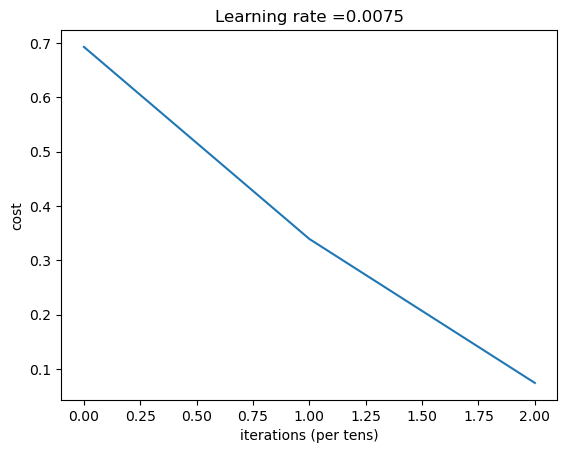

In [35]:
n_x = 12288
n_h = 7
n_y = 1
layers_dims = (n_x,n_h,n_y)

parameters = two_layer_model(train_x, train_set_y, layers_dims = (n_x, n_h, n_y), num_iterations = 2500, print_cost=True,isPlot=True)

In [41]:
## 预测
def predict(X,y,parameters):
    """
    该函数用于预测L层神经网络的结果，当然也包含两层
    
    参数：
        X - 测试集
        y - 标签
        parameters - 训练模型的参数
    
    返回：
        p - 给定数据集X的预测
    """
        
    m=X.shape[1]
    n=len(parameters) //2  # 参数包括w和b 所以层数需要除以2
    p=np.zeros((1,m))
    
    # 根据参数前向传播
    # probas其实是输出 每一列代表一个数据点的输出
    probas, caches = L_model_forward(X, parameters) 
    for i in range(0,probas.shape[1]):
        if probas[0,i] > 0.5:
            p[0,i] = 1
        else:
            p[0,i] = 0
    print("准确度为: "  + str(float(np.sum((p == y))/m)))
    return p

In [42]:
predictions_train = predict(train_x, train_y, parameters) # 训练集
predictions_test = predict(test_x, test_y, parameters)    # 测试集

准确度为: 1.0
准确度为: 0.72


## 多层神经网络

In [45]:
def L_layer_model(X, Y, layers_dims, learning_rate=0.0075, num_iterations=3000, print_cost=False,isPlot=True):
    np.random.seed(1)
    costs = []
    
    parameters = initialize_parameters_deep(layers_dims)
    
    for i in range(0,num_iterations):
        AL , caches = L_model_forward(X,parameters)
        
        cost = compute_cost(AL,Y)
        
        grads = L_model_backward(AL,Y,caches)
        
        parameters = update_parameters(parameters,grads,learning_rate)
        
        # 打印成本值，如果 print_cost=False 则忽略
        if i % 100 == 0:
            # 记录成本
            costs.append(cost)
            # 是否打印成本值
            if print_cost:
                print("第", i ,"次迭代，成本值为：" ,np.squeeze(cost))
    # 迭代完成，根据条件绘制图
    if isPlot:
        plt.plot(np.squeeze(costs))
        plt.ylabel('cost')
        plt.xlabel('iterations (per tens)')
        plt.title("Learning rate =" + str(learning_rate))
        plt.show()
    return parameters 

In [46]:
train_set_x_orig , train_set_y , test_set_x_orig , test_set_y , classes = lr_utils.load_dataset()

In [47]:
train_x_flatten = train_set_x_orig.reshape(train_set_x_orig.shape[0], -1).T 
test_x_flatten = test_set_x_orig.reshape(test_set_x_orig.shape[0], -1).T

train_x = train_x_flatten / 255
train_y = train_set_y
test_x = test_x_flatten / 255
test_y = test_set_y

第 0 次迭代，成本值为： 0.7157315134137129
第 100 次迭代，成本值为： 0.6747377593469114
第 200 次迭代，成本值为： 0.6603365433622127
第 300 次迭代，成本值为： 0.6462887802148751
第 400 次迭代，成本值为： 0.6298131216927771
第 500 次迭代，成本值为： 0.606005622926534
第 600 次迭代，成本值为： 0.5690041263975135
第 700 次迭代，成本值为： 0.519796535043806
第 800 次迭代，成本值为： 0.46415716786282285
第 900 次迭代，成本值为： 0.4084203004829892
第 1000 次迭代，成本值为： 0.3731549921606904
第 1100 次迭代，成本值为： 0.30572374573047123
第 1200 次迭代，成本值为： 0.2681015284774085
第 1300 次迭代，成本值为： 0.2387247482767256
第 1400 次迭代，成本值为： 0.20632263257914704
第 1500 次迭代，成本值为： 0.17943886927493516
第 1600 次迭代，成本值为： 0.15798735818801019
第 1700 次迭代，成本值为： 0.14240413012273687
第 1800 次迭代，成本值为： 0.1286516599788459
第 1900 次迭代，成本值为： 0.11244314998151544
第 2000 次迭代，成本值为： 0.08505631034959686
第 2100 次迭代，成本值为： 0.0575839119860093
第 2200 次迭代，成本值为： 0.04456753454691522
第 2300 次迭代，成本值为： 0.03808275166596521
第 2400 次迭代，成本值为： 0.03441074901839562


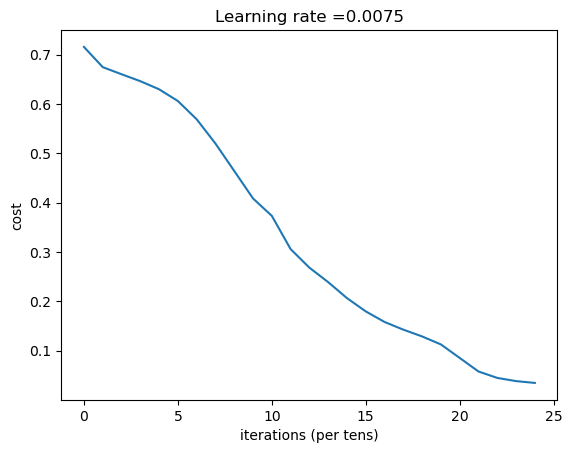

In [48]:
layers_dims = [12288, 20, 7, 5, 1] #  5-layer model
parameters = L_layer_model(train_x, train_y, layers_dims, num_iterations = 2500, print_cost = True,isPlot=True)

- 预测函数

In [51]:
def predict(X, y, parameters):
    """
    该函数用于预测L层神经网络的结果，当然也包含两层
    
    参数：
        X - 测试集
        y - 标签
        parameters - 训练模型的参数
    
    返回：
        p - 给定数据集X的预测
    """
    
    m = X.shape[1]
    n = len(parameters) // 2 # 神经网络的层数
    p = np.zeros((1,m))
    
    # 根据参数前向传播
    probas, caches = L_model_forward(X, parameters)
    
    for i in range(0, probas.shape[1]):
        if probas[0,i] > 0.5:
            p[0,i] = 1
        else:
            p[0,i] = 0
    
    print("准确度为: "  + str(float(np.sum((p == y))/m)))
        
    return p

In [52]:
pred_train = predict(train_x, train_y, parameters) #训练集
pred_test = predict(test_x, test_y, parameters) #测试集

准确度为: 0.9952153110047847
准确度为: 0.78
